# Task 4: Ensemble Model
**Mục tiêu:** Kết hợp TF-IDF + Logistic Regression/LightGBMLightGBM/SGDClassifier với DeBERTa bằng **Weighted Average Ensemble** để tối đa hóa AUC.

In [1]:
import os, gc, warnings, re, time, json
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, accuracy_score, classification_report,
    precision_score, recall_score, f1_score, average_precision_score,
    confusion_matrix, precision_recall_curve, roc_curve,
)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack
from scipy.optimize import minimize
import lightgbm as lgb

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast
from transformers import AutoTokenizer, AutoModel, logging as hf_logging
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
plt.style.use('seaborn-v0_8-darkgrid')

DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data'
CKPT_DIR = ROOT / 'outputs' / 'checkpoints'
OUT_DIR  = ROOT / 'outputs' / 'ensemble'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED     = 42
N_FOLDS  = 5
VAL_FOLD = 0

np.random.seed(SEED); torch.manual_seed(SEED)
print(f'Device: {DEVICE}')
print(DATA_DIR)

Device: cuda
D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\data


## 1. Load & Chuẩn bị dữ liệu

In [2]:
clean_path = DATA_DIR / 'train_clean.pkl'
csv_path = DATA_DIR / 'train_v2_drcat_02.csv'

if clean_path.exists():
    df = pd.read_pickle(clean_path)
    text_col = 'text_clean' if 'text_clean' in df.columns else 'text'
    print(f'Loaded cleaned: {df.shape}')
else:
    df = pd.read_csv(csv_path)
    text_col = 'text'
    print(f'Loaded CSV: {df.shape}')

if 'text_clean' not in df.columns:
    df['text_clean'] = df[text_col].astype(str)
    text_col = 'text_clean'

TEST_SIZE = 0.10
if 'split' not in df.columns:
    print(f'No split column found. Creating {TEST_SIZE:.0%} stratified held-out test split.')
    df = df.copy().reset_index(drop=True)
    df['split'] = 'train_val'
    train_val_idx, test_idx = train_test_split(
        df.index,
        test_size=TEST_SIZE,
        random_state=SEED,
        stratify=df['label'],
    )
    df.loc[test_idx, 'split'] = 'test'
    df['fold'] = -1
else:
    df = df.copy().reset_index(drop=True)
    if 'fold' not in df.columns:
        df['fold'] = -1

train_val_mask = df['split'].eq('train_val')
if (df.loc[train_val_mask, 'fold'] < 0).any():
    print('Creating StratifiedKFold folds on train_val rows only.')
    df.loc[:, 'fold'] = -1
    train_val_idx = df.index[train_val_mask].to_numpy()
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    for fid, (_, vi) in enumerate(skf.split(df.loc[train_val_idx], df.loc[train_val_idx, 'label'])):
        df.loc[train_val_idx[vi], 'fold'] = fid

df.loc[df['split'].eq('test'), 'fold'] = -1
train_val_df = df[df['split'] == 'train_val'].reset_index(drop=True)
train_df = train_val_df[train_val_df['fold'] != VAL_FOLD].reset_index(drop=True)
valid_df = train_val_df[train_val_df['fold'] == VAL_FOLD].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

print(f'Train: {len(train_df):,} | Valid: {len(valid_df):,} | Test: {len(test_df):,}')


Loaded cleaned: (44868, 4)
Train: 32,304 | Valid: 8,077 | Test: 4,487


## 2. Model 1: TF-IDF + Logistic Regression

In [3]:
class TFIDFClassifier:
    """
    Pipeline TF-IDF + Logistic Regression với:
    - Word-level TF-IDF (unigram + bigram)
    - Char-level TF-IDF (3-6 grams) — bắt pattern viết của AI
    - Concatenate features rồi feed vào Logistic Regression
    """
    def __init__(self):
        self.word_vec = TfidfVectorizer(
            analyzer   = 'word',
            ngram_range= (1, 2),
            max_features= 100_000,
            sublinear_tf= True,
            strip_accents='unicode',
            min_df      = 3,
        )
        self.char_vec = TfidfVectorizer(
            analyzer   = 'char_wb',
            ngram_range= (3, 6),
            max_features= 100_000,
            sublinear_tf= True,
            strip_accents='unicode',
            min_df      = 3,
        )
        self.clf = LogisticRegression(
            C=5.0, max_iter=2000,
            solver='saga', n_jobs=-1,
            random_state=SEED,
        )

    def fit(self, texts: List[str], labels: List[int]) -> 'TFIDFClassifier':
        print('[LR] Fitting TF-IDF (word + char)...')
        X_word = self.word_vec.fit_transform(texts)
        X_char = self.char_vec.fit_transform(texts)
        X      = hstack([X_word, X_char])
        print(f'[LR] Feature matrix: {X.shape}')
        print('[LR] Training Logistic Regression...')
        self.clf.fit(X, labels)
        return self

    def predict_proba(self, texts: List[str]) -> np.ndarray:
        X_word = self.word_vec.transform(texts)
        X_char = self.char_vec.transform(texts)
        X      = hstack([X_word, X_char])
        return self.clf.predict_proba(X)[:, 1]  # prob AI=1

# Train & Evaluate 
lr_model = TFIDFClassifier()
lr_model.fit(train_df[text_col].tolist(), train_df['label'].tolist())

lr_train_probs = lr_model.predict_proba(train_df[text_col].tolist())
lr_valid_probs = lr_model.predict_proba(valid_df[text_col].tolist())
lr_test_probs = lr_model.predict_proba(test_df[text_col].tolist())

lr_train_auc = roc_auc_score(train_df['label'], lr_train_probs)
lr_valid_auc = roc_auc_score(valid_df['label'], lr_valid_probs)
lr_test_auc = roc_auc_score(test_df['label'], lr_test_probs)
print(f'[LR] Train AUC: {lr_train_auc:.4f} | Valid AUC: {lr_valid_auc:.4f} | Test AUC: {lr_test_auc:.4f}')

[LR] Fitting TF-IDF (word + char)...
[LR] Feature matrix: (32304, 200000)
[LR] Training Logistic Regression...
[LR] Train AUC: 1.0000 | Valid AUC: 0.9996 | Test AUC: 0.9996


## 2.1 Model 1b: TF-IDF + SGDClassifier

SGDClassifier là baseline tuyến tính dùng Stochastic Gradient Descent. Về vai trò, nó cũng giống với Logistic Regression: nhanh, ít tốn tài nguyên, dùng để so sánh với DeBERTa chứ không phải model chính.


In [4]:
class TFIDFSGDClassifier:
    """
    Pipeline TF-IDF + SGDClassifier:
    - Word-level TF-IDF (unigram + bigram)
    - Char-level TF-IDF (3-6 grams)
    - SGDClassifier voi loss='log_loss' de lay duoc predict_proba
    """
    def __init__(self):
        self.word_vec = TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2),
            max_features=100_000, sublinear_tf=True,
            strip_accents='unicode', min_df=3,
        )
        self.char_vec = TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 6),
            max_features=100_000, sublinear_tf=True,
            strip_accents='unicode', min_df=3,
        )
        self.clf = SGDClassifier(
            loss='log_loss',
            penalty='elasticnet',
            alpha=1e-5,
            l1_ratio=0.15,
            max_iter=2000,
            tol=1e-3,
            class_weight='balanced',
            random_state=SEED,
        )

    def fit(self, texts: List[str], labels: List[int]) -> 'TFIDFSGDClassifier':
        print('[SGD] Fitting TF-IDF (word + char)...')
        X_word = self.word_vec.fit_transform(texts)
        X_char = self.char_vec.fit_transform(texts)
        X = hstack([X_word, X_char])
        print(f'[SGD] Feature matrix: {X.shape}')
        print('[SGD] Training SGDClassifier...')
        self.clf.fit(X, labels)
        return self

    def predict_proba(self, texts: List[str]) -> np.ndarray:
        X_word = self.word_vec.transform(texts)
        X_char = self.char_vec.transform(texts)
        X = hstack([X_word, X_char])
        return self.clf.predict_proba(X)[:, 1]

# Train & Evaluate
sgd_model = TFIDFSGDClassifier()
sgd_model.fit(train_df[text_col].tolist(), train_df['label'].tolist())

sgd_train_probs = sgd_model.predict_proba(train_df[text_col].tolist())
sgd_valid_probs = sgd_model.predict_proba(valid_df[text_col].tolist())
sgd_test_probs = sgd_model.predict_proba(test_df[text_col].tolist())

sgd_train_auc = roc_auc_score(train_df['label'], sgd_train_probs)
sgd_valid_auc = roc_auc_score(valid_df['label'], sgd_valid_probs)
sgd_test_auc = roc_auc_score(test_df['label'], sgd_test_probs)
print(f'[SGD] Train AUC: {sgd_train_auc:.4f} | Valid AUC: {sgd_valid_auc:.4f} | Test AUC: {sgd_test_auc:.4f}')


[SGD] Fitting TF-IDF (word + char)...
[SGD] Feature matrix: (32304, 200000)
[SGD] Training SGDClassifier...
[SGD] Train AUC: 1.0000 | Valid AUC: 0.9996 | Test AUC: 0.9995


## 3. Model 2: TF-IDF + LightGBM

In [5]:
class LightGBMClassifier:
    """
    TF-IDF features + LightGBM với cấu hình tối ưu cho text classification.
    LightGBM xử lý sparse matrix rất hiệu quả.
    """
    def __init__(self):
        self.word_vec = TfidfVectorizer(
            analyzer='word', ngram_range=(1, 2),
            max_features=50_000, sublinear_tf=True, min_df=3,
        )
        self.char_vec = TfidfVectorizer(
            analyzer='char_wb', ngram_range=(3, 5),
            max_features=50_000, sublinear_tf=True, min_df=3,
        )
        self.params = {
            'objective'      : 'binary',
            'metric'         : 'auc',
            'learning_rate'  : 0.05,
            'n_estimators'   : 1000,
            'num_leaves'     : 63,
            'max_depth'      : -1,
            'min_child_samples': 20,
            'feature_fraction': 0.3,
            'bagging_fraction': 0.8,
            'bagging_freq'   : 5,
            'lambda_l1'      : 0.05,
            'lambda_l2'      : 0.05,
            'verbosity'      : -1,
            'random_state'   : SEED,
            'n_jobs'         : -1,
        }
        self.model = None

    def _transform(self, texts, fit=False):
        if fit:
            X_w = self.word_vec.fit_transform(texts)
            X_c = self.char_vec.fit_transform(texts)
        else:
            X_w = self.word_vec.transform(texts)
            X_c = self.char_vec.transform(texts)
        return hstack([X_w, X_c])

    def fit(self, train_texts, train_labels, val_texts, val_labels):
        X_tr = self._transform(train_texts, fit=True)
        X_va = self._transform(val_texts,   fit=False)
        print(f'[LGBM] Feature shape: {X_tr.shape}')

        self.model = lgb.LGBMClassifier(**self.params)
        self.model.fit(
            X_tr, train_labels,
            eval_set=[(X_va, val_labels)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=100),
            ],
        )
        print(f'[LGBM] Best iteration: {self.model.best_iteration_}')
        return self

    def predict_proba(self, texts):
        X = self._transform(texts)
        return self.model.predict_proba(X)[:, 1]

# Huấn luyện LightGBM 
lgbm_model = LightGBMClassifier()
lgbm_model.fit(
    train_df[text_col].tolist(), train_df['label'].tolist(),
    valid_df[text_col].tolist(), valid_df['label'].tolist()
)

lgbm_train_probs = lgbm_model.predict_proba(train_df[text_col].tolist())
lgbm_valid_probs = lgbm_model.predict_proba(valid_df[text_col].tolist())
lgbm_test_probs = lgbm_model.predict_proba(test_df[text_col].tolist())

lgbm_train_auc = roc_auc_score(train_df['label'], lgbm_train_probs)
lgbm_valid_auc = roc_auc_score(valid_df['label'], lgbm_valid_probs)
lgbm_test_auc = roc_auc_score(test_df['label'], lgbm_test_probs)
print(f'[LGBM] Train AUC: {lgbm_train_auc:.4f} | Valid AUC: {lgbm_valid_auc:.4f} | Test AUC: {lgbm_test_auc:.4f}')

[LGBM] Feature shape: (32304, 100000)
[100]	valid_0's auc: 0.998545
[200]	valid_0's auc: 0.999269
[300]	valid_0's auc: 0.999464
[400]	valid_0's auc: 0.999531
[500]	valid_0's auc: 0.999567
[LGBM] Best iteration: 547
[LGBM] Train AUC: 1.0000 | Valid AUC: 0.9996 | Test AUC: 0.9992


## 4. Model 3: Load DeBERTa OOF Predictions

In [6]:
class AITextDataset(Dataset):
    def __init__(self, texts, tokenizer, max_len=512, labels=None):
        self.texts, self.labels, self.tok, self.max_len = texts, labels, tokenizer, max_len
    def __len__(self): return len(self.texts)
    def __getitem__(self, i):
        enc = self.tok(self.texts[i], max_length=self.max_len, padding='max_length',
                       truncation=True, return_tensors='pt')
        item = {k: v.squeeze(0) for k, v in enc.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[i], dtype=torch.long)
        return item

class MeanPooling(nn.Module):
    def forward(self, h, m):
        return (h * m.unsqueeze(-1).float()).sum(1) / m.float().sum(1, keepdim=True).clamp(1e-9)

class DeBERTaDetector(nn.Module):
    def __init__(self, model_name='microsoft/deberta-v3-base', drop=0.1, pooling='mean', num_labels=2):
        super().__init__()
        if pooling not in {'mean', 'cls'}:
            raise ValueError("pooling must be 'mean' or 'cls'")
        self.pooling = pooling
        self.backbone = AutoModel.from_pretrained(
            model_name,
            hidden_dropout_prob=drop,
            attention_probs_dropout_prob=drop,
        )
        self.pool = MeanPooling()
        hidden_size = self.backbone.config.hidden_size
        self.dropout = nn.Dropout(drop)
        self.classifier = nn.Linear(hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None, **_):
        h = self.backbone(input_ids, attention_mask, token_type_ids).last_hidden_state
        pooled = h[:, 0] if self.pooling == 'cls' else self.pool(h, attention_mask)
        return self.classifier(self.dropout(pooled))


def select_deberta_checkpoint() -> Path:
    # The project now standardizes on the tuned DeBERTa checkpoint.
    # Do not silently fallback to the default Task 3 checkpoint.
    return CKPT_DIR / 'deberta_tuned_best.pt'


def load_checkpoint_config(ckpt: dict, ckpt_path: Path) -> Dict:
    cfg = ckpt.get('cfg', {}) if isinstance(ckpt, dict) else {}
    if not isinstance(cfg, dict):
        cfg = {}

    # If the promoted checkpoint is old/minimal, use best_config.json from tuning when available.
    best_config_path = ROOT / 'outputs' / 'tv2_deberta_tuning' / 'best_config.json'
    if ckpt_path.name == 'deberta_tuned_best.pt' and best_config_path.exists():
        with open(best_config_path, 'r', encoding='utf-8') as f:
            cfg_from_file = json.load(f)
        cfg = {**cfg, **cfg_from_file}

    model_name = cfg.get('model_name', 'microsoft/deberta-v3-base')
    # Kaggle local paths stored in checkpoint are not valid after downloading to another machine.
    if isinstance(model_name, str) and model_name.startswith('/kaggle/') and not Path(model_name).exists():
        model_name = 'microsoft/deberta-v3-base'

    return {
        'model_name': model_name,
        'dropout': float(cfg.get('dropout', 0.1)),
        'pooling': cfg.get('pooling', 'mean'),
        'max_length': int(cfg.get('max_length', 512)),
        'num_labels': int(cfg.get('num_labels', 2)),
    }


@torch.no_grad()
def get_deberta_probs(
    texts: List[str],
    model_path: Optional[Path],
    batch_size: int = 32,
) -> np.ndarray:
    """Predict P(AI) from the selected DeBERTa checkpoint using its saved tuned config."""
    if model_path is None or not model_path.exists():
        print('[WARN] Kh?ng t?m th?y DeBERTa checkpoint - d?ng uniform 0.5')
        return np.full(len(texts), 0.5)

    print(f'[DeBERTa] Loading checkpoint: {model_path}')
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    runtime_cfg = load_checkpoint_config(ckpt, model_path)
    print('[DeBERTa] Runtime config:', runtime_cfg)

    tokenizer = AutoTokenizer.from_pretrained(runtime_cfg['model_name'])
    model = DeBERTaDetector(
        model_name=runtime_cfg['model_name'],
        drop=runtime_cfg['dropout'],
        pooling=runtime_cfg['pooling'],
        num_labels=runtime_cfg['num_labels'],
    ).to(DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()

    ds = AITextDataset(texts, tokenizer, runtime_cfg['max_length'])
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    all_probs = []
    for batch in tqdm(dl, desc='[DeBERTa] Inference'):
        ids = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        tids = batch.get('token_type_ids')
        if tids is not None:
            tids = tids.to(DEVICE)
        with autocast(enabled=torch.cuda.is_available()):
            logits = model(ids, mask, tids)
        probs = torch.softmax(logits.float(), -1)[:, 1].cpu().numpy()
        all_probs.extend(probs)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(all_probs)


ckpt_path = select_deberta_checkpoint()
print(f'[DeBERTa] Selected checkpoint path: {ckpt_path}')

deberta_train_probs = get_deberta_probs(train_df[text_col].tolist(), ckpt_path)
deberta_valid_probs = get_deberta_probs(valid_df[text_col].tolist(), ckpt_path)
deberta_test_probs = get_deberta_probs(test_df[text_col].tolist(), ckpt_path)

if deberta_valid_probs.mean() != 0.5:
    deb_train_auc = roc_auc_score(train_df['label'], deberta_train_probs)
    deb_valid_auc = roc_auc_score(valid_df['label'], deberta_valid_probs)
    deb_test_auc = roc_auc_score(test_df['label'], deberta_test_probs)
    print(f'[DeBERTa] Train AUC: {deb_train_auc:.4f} | Valid AUC: {deb_valid_auc:.4f} | Test AUC: {deb_test_auc:.4f}')
else:
    deb_train_auc = deb_valid_auc = deb_test_auc = 0.5
    print('[DeBERTa] No tuned checkpoint found - assigning weight=0 in ensemble')


[DeBERTa] Selected checkpoint path: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\checkpoints\deberta_tuned_best.pt
[WARN] Kh?ng t?m th?y DeBERTa checkpoint - d?ng uniform 0.5
[WARN] Kh?ng t?m th?y DeBERTa checkpoint - d?ng uniform 0.5
[WARN] Kh?ng t?m th?y DeBERTa checkpoint - d?ng uniform 0.5
[DeBERTa] No tuned checkpoint found - assigning weight=0 in ensemble


## 4.1 DeBERTa training process reference

Task 4 does not train DeBERTa again. This section reads the DeBERTa training log from Task 3 and exports a compact loss/AUC summary so the ensemble notebook still documents the Transformer training process used for comparison.

In [7]:
TUNING_LOG_DIR = ROOT / 'outputs' / 'tv2_deberta_tuning' / 'logs'
TUNING_SUMMARY_PATH = ROOT / 'outputs' / 'tv2_deberta_tuning' / 'experiment_summary.csv'
TRAINING_REPORT_DIR = OUT_DIR / 'deberta_training_process'
TRAINING_REPORT_DIR.mkdir(parents=True, exist_ok=True)

if not TUNING_SUMMARY_PATH.exists():
    print(f'No tuning summary found: {TUNING_SUMMARY_PATH}')
    print('Run tv2_deberta_ablation.ipynb first to create tuned DeBERTa logs.')
else:
    tuning_summary = pd.read_csv(TUNING_SUMMARY_PATH)
    if tuning_summary.empty:
        print('Tuning summary is empty. Run tv2_deberta_ablation.ipynb first.')
    else:
        sort_cols = [col for col in ['best_val_auc', 'val_f1', 'val_loss'] if col in tuning_summary.columns]
        ascending = [False, False, True][:len(sort_cols)]
        best_row = tuning_summary.sort_values(sort_cols, ascending=ascending).iloc[0]
        run_name = best_row['name']
        history_path = TUNING_LOG_DIR / f'{run_name}_history.csv'

        if not history_path.exists():
            print(f'No tuning history found for best run: {history_path}')
        else:
            hist_df = pd.read_csv(history_path).sort_values('epoch').reset_index(drop=True)
            best_epoch = int(best_row.get('best_epoch', hist_df.loc[hist_df['val_auc'].idxmax(), 'epoch']))

            summary_df = pd.DataFrame([
                {'item': 'source_log', 'value': str(history_path)},
                {'item': 'run_name', 'value': run_name},
                {'item': 'best_epoch', 'value': best_epoch},
                {'item': 'best_train_loss', 'value': best_row.get('train_loss', np.nan)},
                {'item': 'best_valid_loss', 'value': best_row.get('val_loss', np.nan)},
                {'item': 'best_valid_auc', 'value': best_row.get('best_val_auc', best_row.get('val_auc', np.nan))},
                {'item': 'best_valid_f1', 'value': best_row.get('val_f1', np.nan)},
                {'item': 'elapsed_min', 'value': best_row.get('elapsed_min', np.nan)},
            ])

            epoch_cols = [
                'epoch', 'train_loss', 'val_loss', 'val_accuracy', 'val_precision',
                'val_recall', 'val_f1', 'val_auc', 'val_pr_auc'
            ]
            epoch_cols = [col for col in epoch_cols if col in hist_df.columns]
            epoch_table = hist_df[epoch_cols].copy()

            summary_path = TRAINING_REPORT_DIR / 'deberta_tuned_training_summary.csv'
            epoch_path = TRAINING_REPORT_DIR / 'deberta_tuned_epoch_metrics.csv'
            summary_df.to_csv(summary_path, index=False)
            epoch_table.to_csv(epoch_path, index=False)

            fig, ax = plt.subplots(figsize=(8, 5))
            ax.plot(hist_df['epoch'], hist_df['train_loss'], marker='o', linewidth=2, label='Train loss')
            ax.plot(hist_df['epoch'], hist_df['val_loss'], marker='s', linewidth=2, label='Validation loss')
            ax.axvline(best_epoch, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Best epoch {best_epoch}')
            ax.set_title(f'Tuned DeBERTa train/validation loss - {run_name}')
            ax.set_xlabel('Epoch')
            ax.set_ylabel('Loss')
            ax.grid(alpha=0.3)
            ax.legend()
            plt.tight_layout()
            loss_path = TRAINING_REPORT_DIR / 'deberta_tuned_loss_curve.png'
            plt.savefig(loss_path, dpi=180, bbox_inches='tight')
            plt.show()

            if 'val_auc' in hist_df.columns:
                fig, ax = plt.subplots(figsize=(8, 5))
                ax.plot(hist_df['epoch'], hist_df['val_auc'], marker='D', linewidth=2, color='green', label='Validation ROC-AUC')
                ax.axvline(best_epoch, color='black', linestyle='--', linewidth=1.2, alpha=0.7, label=f'Best epoch {best_epoch}')
                ax.set_title(f'Tuned DeBERTa validation ROC-AUC - {run_name}')
                ax.set_xlabel('Epoch')
                ax.set_ylabel('ROC-AUC')
                ax.set_ylim(0, 1.02)
                ax.grid(alpha=0.3)
                ax.legend()
                plt.tight_layout()
                auc_path = TRAINING_REPORT_DIR / 'deberta_tuned_valid_auc_curve.png'
                plt.savefig(auc_path, dpi=180, bbox_inches='tight')
                plt.show()
            else:
                auc_path = None

            display(summary_df)
            display(epoch_table)
            print(f'Saved summary: {summary_path}')
            print(f'Saved epoch table: {epoch_path}')
            print(f'Saved loss curve: {loss_path}')
            if auc_path is not None:
                print(f'Saved AUC curve: {auc_path}')


No tuning summary found: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\tv2_deberta_tuning\experiment_summary.csv
Run tv2_deberta_ablation.ipynb first to create tuned DeBERTa logs.


## 5. Ensemble — Weighted Average

### 5.1 WeightedEnsemble class

Class này trộn xác suất dự đoán của các model bằng weighted average và tối ưu trọng số theo validation ROC-AUC.


In [8]:
class WeightedEnsemble:
    """
    Ensemble bằng Weighted Average trên probability scores.

    Objective khi tối ưu: minimize negative AUC (= maximize AUC).
    Constraint được xử lý bằng cách clip weights >= 0 và normalize sum(weights)=1.
    """

    def __init__(self, model_names: List[str]):
        self.model_names = model_names
        self.weights = np.ones(len(model_names)) / len(model_names)

    def predict(self, probs_list: List[np.ndarray]) -> np.ndarray:
        assert len(probs_list) == len(self.weights)
        stacked = np.stack(probs_list, axis=1)
        return stacked @ self.weights

    def optimize_weights(self, probs_list: List[np.ndarray], labels: np.ndarray) -> np.ndarray:
        stacked = np.stack(probs_list, axis=1)

        def objective(w):
            w = np.clip(w, 0, 1)
            w = w / w.sum()
            preds = stacked @ w
            return -roc_auc_score(labels, preds)

        aucs = np.array([roc_auc_score(labels, p) for p in probs_list])
        w0 = aucs / aucs.sum()
        print(f'[ENSEMBLE] Initial weights (AUC-proportional): {w0.round(4)}')

        result = minimize(
            objective,
            w0,
            method='Nelder-Mead',
            options={'maxiter': 5000, 'xatol': 1e-7, 'fatol': 1e-7},
        )
        optimal_w = np.clip(result.x, 0, None)
        optimal_w = optimal_w / optimal_w.sum()
        self.weights = optimal_w

        print(f'[ENSEMBLE] Optimal weights: {optimal_w.round(4)}')
        print(f'[ENSEMBLE] Best AUC: {-result.fun:.4f}')
        return optimal_w

    def summary(self):
        print('\nENSEMBLE WEIGHTS:')
        for name, w in zip(self.model_names, self.weights):
            print(f'  {name:<30}: {w:.4f} ({w*100:.1f}%)')


### 5.2 Prepare model probabilities

Các model TF-IDF là baseline để so sánh; DeBERTa là model Transformer chính. Tất cả đều được chuyển về cùng dạng `P(AI)` trên validation fold.


In [9]:
model_names = [
    'LR (TF-IDF)',
    'SGD (TF-IDF)',
    'LightGBM (TF-IDF)',
    'DeBERTa-v3-base',
]
valid_probs = [
    lr_valid_probs,
    sgd_valid_probs,
    lgbm_valid_probs,
    deberta_valid_probs,
]
valid_labels = valid_df['label'].values

print('AUC từng model đơn lẻ trên validation fold:')
for name, probs in zip(model_names, valid_probs):
    auc = roc_auc_score(valid_labels, probs)
    print(f'  {name:<30}: AUC={auc:.4f}')

test_probs = [
    lr_test_probs,
    sgd_test_probs,
    lgbm_test_probs,
    deberta_test_probs,
]
test_labels = test_df['label'].values

print('AUC on held-out test set before ensemble weighting:')
for name, probs in zip(model_names, test_probs):
    auc = roc_auc_score(test_labels, probs)
    print(f'  {name:<30}: AUC={auc:.4f}')


AUC từng model đơn lẻ trên validation fold:
  LR (TF-IDF)                   : AUC=0.9996
  SGD (TF-IDF)                  : AUC=0.9996
  LightGBM (TF-IDF)             : AUC=0.9996
  DeBERTa-v3-base               : AUC=0.5000
AUC on held-out test set before ensemble weighting:
  LR (TF-IDF)                   : AUC=0.9996
  SGD (TF-IDF)                  : AUC=0.9995
  LightGBM (TF-IDF)             : AUC=0.9992
  DeBERTa-v3-base               : AUC=0.5000


### 5.3 Simple average baseline

Simple average dùng trọng số đều cho tất cả model. Đây là baseline đơn giản để so với weighted ensemble.


In [10]:
simple_preds = np.mean(np.stack(valid_probs, axis=1), axis=1)
simple_auc = roc_auc_score(valid_labels, simple_preds)
print(f'[Simple Average] Valid AUC: {simple_auc:.4f}')

simple_test_preds = np.mean(np.stack(test_probs, axis=1), axis=1)
simple_test_auc = roc_auc_score(test_labels, simple_test_preds)
print(f'[Simple Average] Test AUC : {simple_test_auc:.4f}')


[Simple Average] Valid AUC: 0.9996
[Simple Average] Test AUC : 0.9996


### 5.4 Weighted average optimization

Tối ưu trọng số ensemble trên validation fold. Vì AUC không khả vi theo cách trực tiếp, notebook dùng Nelder-Mead.


In [11]:
ensemble = WeightedEnsemble(model_names)
optimal_weights = ensemble.optimize_weights(valid_probs, valid_labels)
ensemble_preds = ensemble.predict(valid_probs)
ensemble_auc = roc_auc_score(valid_labels, ensemble_preds)

print(f'\n[Optimal Ensemble] Valid AUC: {ensemble_auc:.4f}')
ensemble.summary()

ensemble_test_preds = ensemble.predict(test_probs)
ensemble_test_auc = roc_auc_score(test_labels, ensemble_test_preds)
print(f'[Optimal Ensemble] Test AUC : {ensemble_test_auc:.4f}')


[ENSEMBLE] Initial weights (AUC-proportional): [0.2857 0.2857 0.2857 0.1429]
[ENSEMBLE] Optimal weights: [0.0359 0.     0.7513 0.2129]
[ENSEMBLE] Best AUC: 0.9997

[Optimal Ensemble] Valid AUC: 0.9997

ENSEMBLE WEIGHTS:
  LR (TF-IDF)                   : 0.0359 (3.6%)
  SGD (TF-IDF)                  : 0.0000 (0.0%)
  LightGBM (TF-IDF)             : 0.7513 (75.1%)
  DeBERTa-v3-base               : 0.2129 (21.3%)
[Optimal Ensemble] Test AUC : 0.9995


### 5.5 Quick AUC summary


In [12]:
print('\n' + '=' * 55)
print('K?T QU? T?NG H?P ? VALIDATION FOLD')
print('=' * 55)
for name, probs in zip(model_names, valid_probs):
    auc = roc_auc_score(valid_labels, probs)
    print(f'  {name:<30}: AUC={auc:.4f}')
print(f'  {"Simple Average":<30}: AUC={simple_auc:.4f}')
print(f'  {"Weighted Ensemble (opt)":<30}: AUC={ensemble_auc:.4f}')
print('=' * 55)

print('\n' + '=' * 55)
print('RESULTS ON HELD-OUT TEST SET')
print('=' * 55)
for name, probs in zip(model_names, test_probs):
    auc = roc_auc_score(test_labels, probs)
    print(f'  {name:<30}: AUC={auc:.4f}')
print(f'  {"Simple Average":<30}: AUC={simple_test_auc:.4f}')
print(f'  {"Weighted Ensemble (opt)":<30}: AUC={ensemble_test_auc:.4f}')
print('=' * 55)



K?T QU? T?NG H?P ? VALIDATION FOLD
  LR (TF-IDF)                   : AUC=0.9996
  SGD (TF-IDF)                  : AUC=0.9996
  LightGBM (TF-IDF)             : AUC=0.9996
  DeBERTa-v3-base               : AUC=0.5000
  Simple Average                : AUC=0.9996
  Weighted Ensemble (opt)       : AUC=0.9997

RESULTS ON HELD-OUT TEST SET
  LR (TF-IDF)                   : AUC=0.9996
  SGD (TF-IDF)                  : AUC=0.9995
  LightGBM (TF-IDF)             : AUC=0.9992
  DeBERTa-v3-base               : AUC=0.5000
  Simple Average                : AUC=0.9996
  Weighted Ensemble (opt)       : AUC=0.9995


## 6. Visualization - Ensemble Comparison


### 6.1 ROC curves


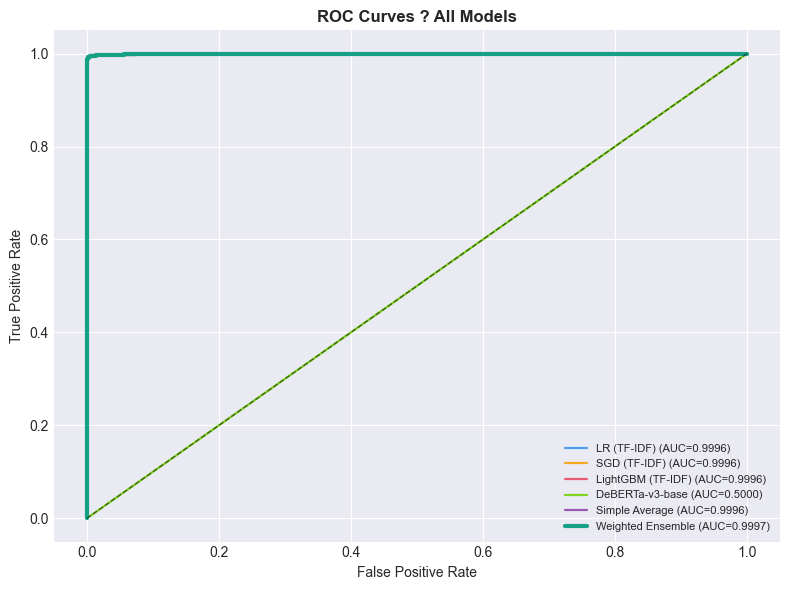

In [13]:
COLORS_PLOT = ['#4C9BE8', '#F5A623', '#E85D75', '#7ED321', '#9B59B6', '#16A085']

all_models_probs = valid_probs + [simple_preds, ensemble_preds]
all_models_names = model_names + ['Simple Average', 'Weighted Ensemble']

fig, ax = plt.subplots(figsize=(8, 6))
for i, (probs, name) in enumerate(zip(all_models_probs, all_models_names)):
    fpr, tpr, _ = roc_curve(valid_labels, probs)
    auc_val = roc_auc_score(valid_labels, probs)
    lw = 3 if name == 'Weighted Ensemble' else 1.6
    ax.plot(fpr, tpr, color=COLORS_PLOT[i % len(COLORS_PLOT)], lw=lw, label=f'{name} (AUC={auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves ? All Models', fontweight='bold')
ax.legend(fontsize=8, loc='lower right')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.2 Ensemble weight chart


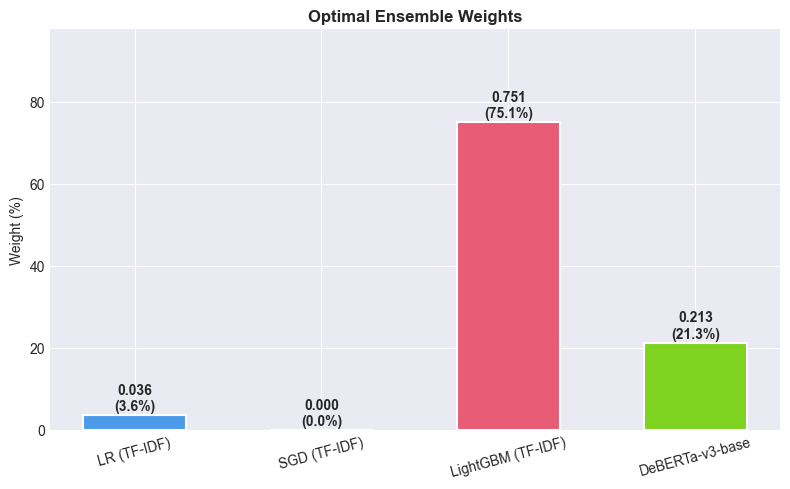

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    model_names,
    ensemble.weights * 100,
    color=COLORS_PLOT[:len(model_names)],
    edgecolor='white',
    linewidth=1.5,
    width=0.55,
)
for bar, w in zip(bars, ensemble.weights):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f'{w:.3f}\n({w*100:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
    )
ax.set_title('Optimal Ensemble Weights', fontweight='bold')
ax.set_ylabel('Weight (%)')
ax.set_ylim(0, max(ensemble.weights * 100) * 1.3)
ax.tick_params(axis='x', rotation=15)
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'ensemble_weights.png', dpi=150, bbox_inches='tight')
plt.show()


## 6.1 Full Evaluation Metrics, PR Curve, Confusion Matrix & Error Analysis


### 6.1.1 Metric helper


In [15]:
def compute_binary_metrics(y_true, y_prob, threshold: float = 0.5) -> Dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_prob),
        'pr_auc': average_precision_score(y_true, y_prob),
    }


### 6.1.2 Metric table


In [16]:
comparison_probs = dict(zip(model_names, valid_probs))
comparison_probs['Simple Average'] = simple_preds
comparison_probs['Weighted Ensemble'] = ensemble_preds

metric_rows = []
for name, probs in comparison_probs.items():
    row = {'model': name}
    row.update(compute_binary_metrics(valid_labels, probs, threshold=0.5))
    metric_rows.append(row)

metrics_df = pd.DataFrame(metric_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(metrics_df)
metrics_df.to_csv(OUT_DIR / 'model_comparison_metrics.csv', index=False)


test_comparison_probs = dict(zip(model_names, test_probs))
test_comparison_probs['Simple Average'] = simple_test_preds
test_comparison_probs['Weighted Ensemble'] = ensemble_test_preds

test_metric_rows = []
for name, probs in test_comparison_probs.items():
    row = {'model': name}
    row.update(compute_binary_metrics(test_labels, probs, threshold=0.5))
    test_metric_rows.append(row)

test_metrics_df = pd.DataFrame(test_metric_rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
display(test_metrics_df)
test_metrics_df.to_csv(OUT_DIR / 'model_comparison_metrics_test.csv', index=False)


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Weighted Ensemble,0.995048,0.997441,0.989841,0.993627,0.999701,0.999582
1,LR (TF-IDF),0.996038,0.998083,0.991746,0.994904,0.999621,0.999501
2,Simple Average,0.996038,0.997765,0.992063,0.994906,0.999617,0.999496
3,LightGBM (TF-IDF),0.995048,0.997441,0.989841,0.993627,0.999579,0.999457
4,SGD (TF-IDF),0.995791,0.997128,0.992063,0.994589,0.999560,0.999430
5,DeBERTa-v3-base,0.389996,0.389996,1.000000,0.561147,0.500000,0.389996


,model,accuracy,precision,recall,f1,roc_auc,pr_auc
0,LR (TF-IDF),0.995320,0.999422,0.988571,0.993967,0.999606,0.999559
1,Simple Average,0.994874,0.998845,0.988000,0.993393,0.999570,0.999523
2,SGD (TF-IDF),0.994651,0.997693,0.988571,0.993111,0.999531,0.999472
3,Weighted Ensemble,0.993983,0.998265,0.986286,0.992239,0.999491,0.999417
4,LightGBM (TF-IDF),0.993983,0.998265,0.986286,0.992239,0.999237,0.999126
5,DeBERTa-v3-base,0.390016,0.390016,1.000000,0.561167,0.500000,0.390016


### 6.1.3 Precision-Recall curves


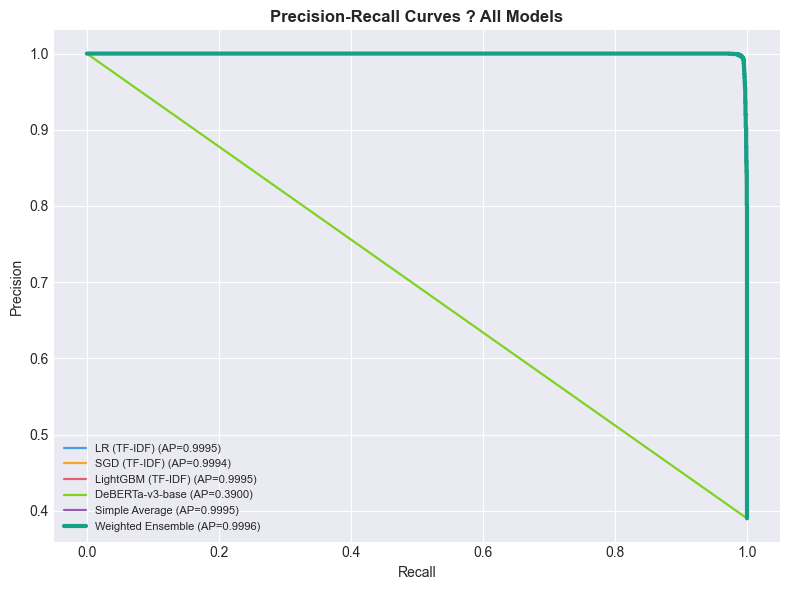

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for i, (name, probs) in enumerate(comparison_probs.items()):
    precision, recall, _ = precision_recall_curve(valid_labels, probs)
    ap = average_precision_score(valid_labels, probs)
    lw = 3 if name == 'Weighted Ensemble' else 1.6
    ax.plot(recall, precision, lw=lw, color=COLORS_PLOT[i % len(COLORS_PLOT)], label=f'{name} (AP={ap:.4f})')
ax.set_title('Precision-Recall Curves ? All Models', fontweight='bold')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.legend(fontsize=8, loc='lower left')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.1.4 Confusion matrix & classification report


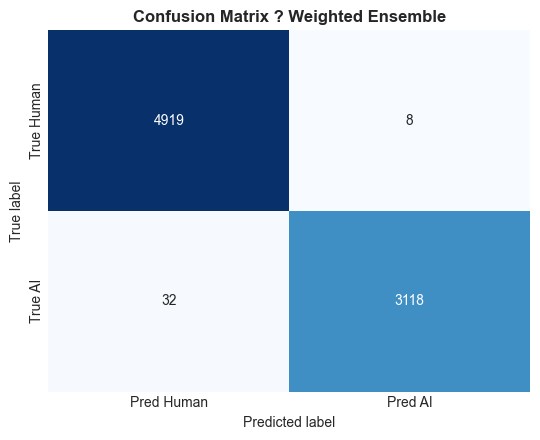

              precision    recall  f1-score   support

       Human       0.99      1.00      1.00      4927
          AI       1.00      0.99      0.99      3150

    accuracy                           1.00      8077
   macro avg       1.00      0.99      0.99      8077
weighted avg       1.00      1.00      1.00      8077



In [18]:
ensemble_pred = (ensemble_preds >= 0.5).astype(int)
cm = confusion_matrix(valid_labels, ensemble_pred, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['Pred Human', 'Pred AI'],
    yticklabels=['True Human', 'True AI'],
    ax=ax,
)
ax.set_title('Confusion Matrix ? Weighted Ensemble', fontweight='bold')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix_weighted_ensemble.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(valid_labels, ensemble_pred, target_names=['Human', 'AI'], zero_division=0))


### 6.1.5 Error analysis

Lưu toàn bộ lỗi và top lỗi có confidence cao để phục vụ phần phân tích định tính trong báo cáo.


In [19]:
error_df = valid_df[[text_col, 'label']].copy()
error_df['prob_ensemble'] = ensemble_preds
error_df['pred_ensemble'] = ensemble_pred
error_df['correct'] = error_df['label'] == error_df['pred_ensemble']
error_df['error_type'] = 'correct'
error_df.loc[(error_df['label'] == 0) & (error_df['pred_ensemble'] == 1), 'error_type'] = 'false_positive'
error_df.loc[(error_df['label'] == 1) & (error_df['pred_ensemble'] == 0), 'error_type'] = 'false_negative'
error_df['confidence'] = np.where(error_df['pred_ensemble'] == 1, error_df['prob_ensemble'], 1 - error_df['prob_ensemble'])

top_errors = (
    error_df[~error_df['correct']]
    .sort_values('confidence', ascending=False)
    .head(30)
)

error_df.to_csv(OUT_DIR / 'ensemble_error_analysis.csv', index=False)
top_errors.to_csv(OUT_DIR / 'ensemble_top_errors.csv', index=False)
print(f'S? l?i c?a Weighted Ensemble: {(~error_df["correct"]).sum():,} / {len(error_df):,}')
display(top_errors.head(10))


S? l?i c?a Weighted Ensemble: 40 / 8,077


,text_clean,label,prob_ensemble,pred_ensemble,correct,error_type,confidence
7517,Nobody ever said that writing an argumentative...,1,0.107089,0,False,false_negative,0.892911
7164,Some students may choose to stay home to catch...,1,0.107465,0,False,false_negative,0.892535
5863,I believe that many accomplishments could be a...,1,0.107636,0,False,false_negative,0.892364
7186,Dear:\n\nI believe that I can achieve your att...,1,0.107917,0,False,false_negative,0.892083
4985,"My first opinion,\n\nwould be that to be a goo...",1,0.108375,0,False,false_negative,0.891625
6829,Would it be surprising to know if students to ...,1,0.108459,0,False,false_negative,0.891541
6349,What is one type of job you would like to empl...,1,0.109318,0,False,false_negative,0.890682
5972,"My mother always said, ""You will never learn i...",1,0.110640,0,False,false_negative,0.889360
7238,Working with a group or working alone.\n\nTher...,1,0.112639,0,False,false_negative,0.887361
4942,"As a child, I always loved to go to the park. ...",1,0.112825,0,False,false_negative,0.887175


## 7. Save Ensemble Predictions & Summary


In [20]:
oof_df = pd.DataFrame({
    'label': valid_labels,
    'prob_lr': lr_valid_probs,
    'prob_sgd': sgd_valid_probs,
    'prob_lgbm': lgbm_valid_probs,
    'prob_deberta': deberta_valid_probs,
    'prob_simple_avg': simple_preds,
    'prob_ensemble': ensemble_preds,
    'pred_ensemble': (ensemble_preds >= 0.5).astype(int),
})

oof_path = OUT_DIR / 'oof_predictions.csv'
oof_df.to_csv(oof_path, index=False)
print(f'[INFO] Saved OOF predictions: {oof_path}')


test_pred_df = pd.DataFrame({
    'label': test_labels,
    'prob_lr': lr_test_probs,
    'prob_sgd': sgd_test_probs,
    'prob_lgbm': lgbm_test_probs,
    'prob_deberta': deberta_test_probs,
    'prob_simple_avg': simple_test_preds,
    'prob_ensemble': ensemble_test_preds,
    'pred_ensemble': (ensemble_test_preds >= 0.5).astype(int),
})

test_pred_path = OUT_DIR / 'test_predictions.csv'
test_pred_df.to_csv(test_pred_path, index=False)
print(f'[INFO] Saved held-out test predictions: {test_pred_path}')


[INFO] Saved OOF predictions: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\ensemble\oof_predictions.csv
[INFO] Saved held-out test predictions: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\ensemble\test_predictions.csv


In [21]:
import json
weights_cfg = {
    'model_names': model_names,
    'weights': ensemble.weights.tolist(),
    'individual_aucs': {
        n: float(roc_auc_score(valid_labels, p))
        for n, p in zip(model_names, valid_probs)
    },
    'simple_avg_auc': float(simple_auc),
    'ensemble_auc': float(ensemble_auc),
}

config_path = OUT_DIR / 'ensemble_config.json'
with open(config_path, 'w', encoding='utf-8') as f:
    json.dump(weights_cfg, f, indent=2, ensure_ascii=False)

print(f'[INFO] Saved ensemble config: {config_path}')
print('Task 4 - Ensemble hoàn tất!')
print(f'Final Ensemble AUC: {ensemble_auc:.4f}')


[INFO] Saved ensemble config: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\ensemble\ensemble_config.json
Task 4 - Ensemble hoàn tất!
Final Ensemble AUC: 0.9997
